In [78]:
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [79]:
bsse_data_nwchem = pd.read_csv('BSSE_by_FF_distance_nwchem.csv')

/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_38856/1421357067.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')
/var/folders/v1/k9l8hql13n1gcrjl_yh_gs5m0000gn/T/ipykernel_38856/1421357067.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 7 Axes> than <Figure size 2000x2000 with 8 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=axes.ravel().tolist())


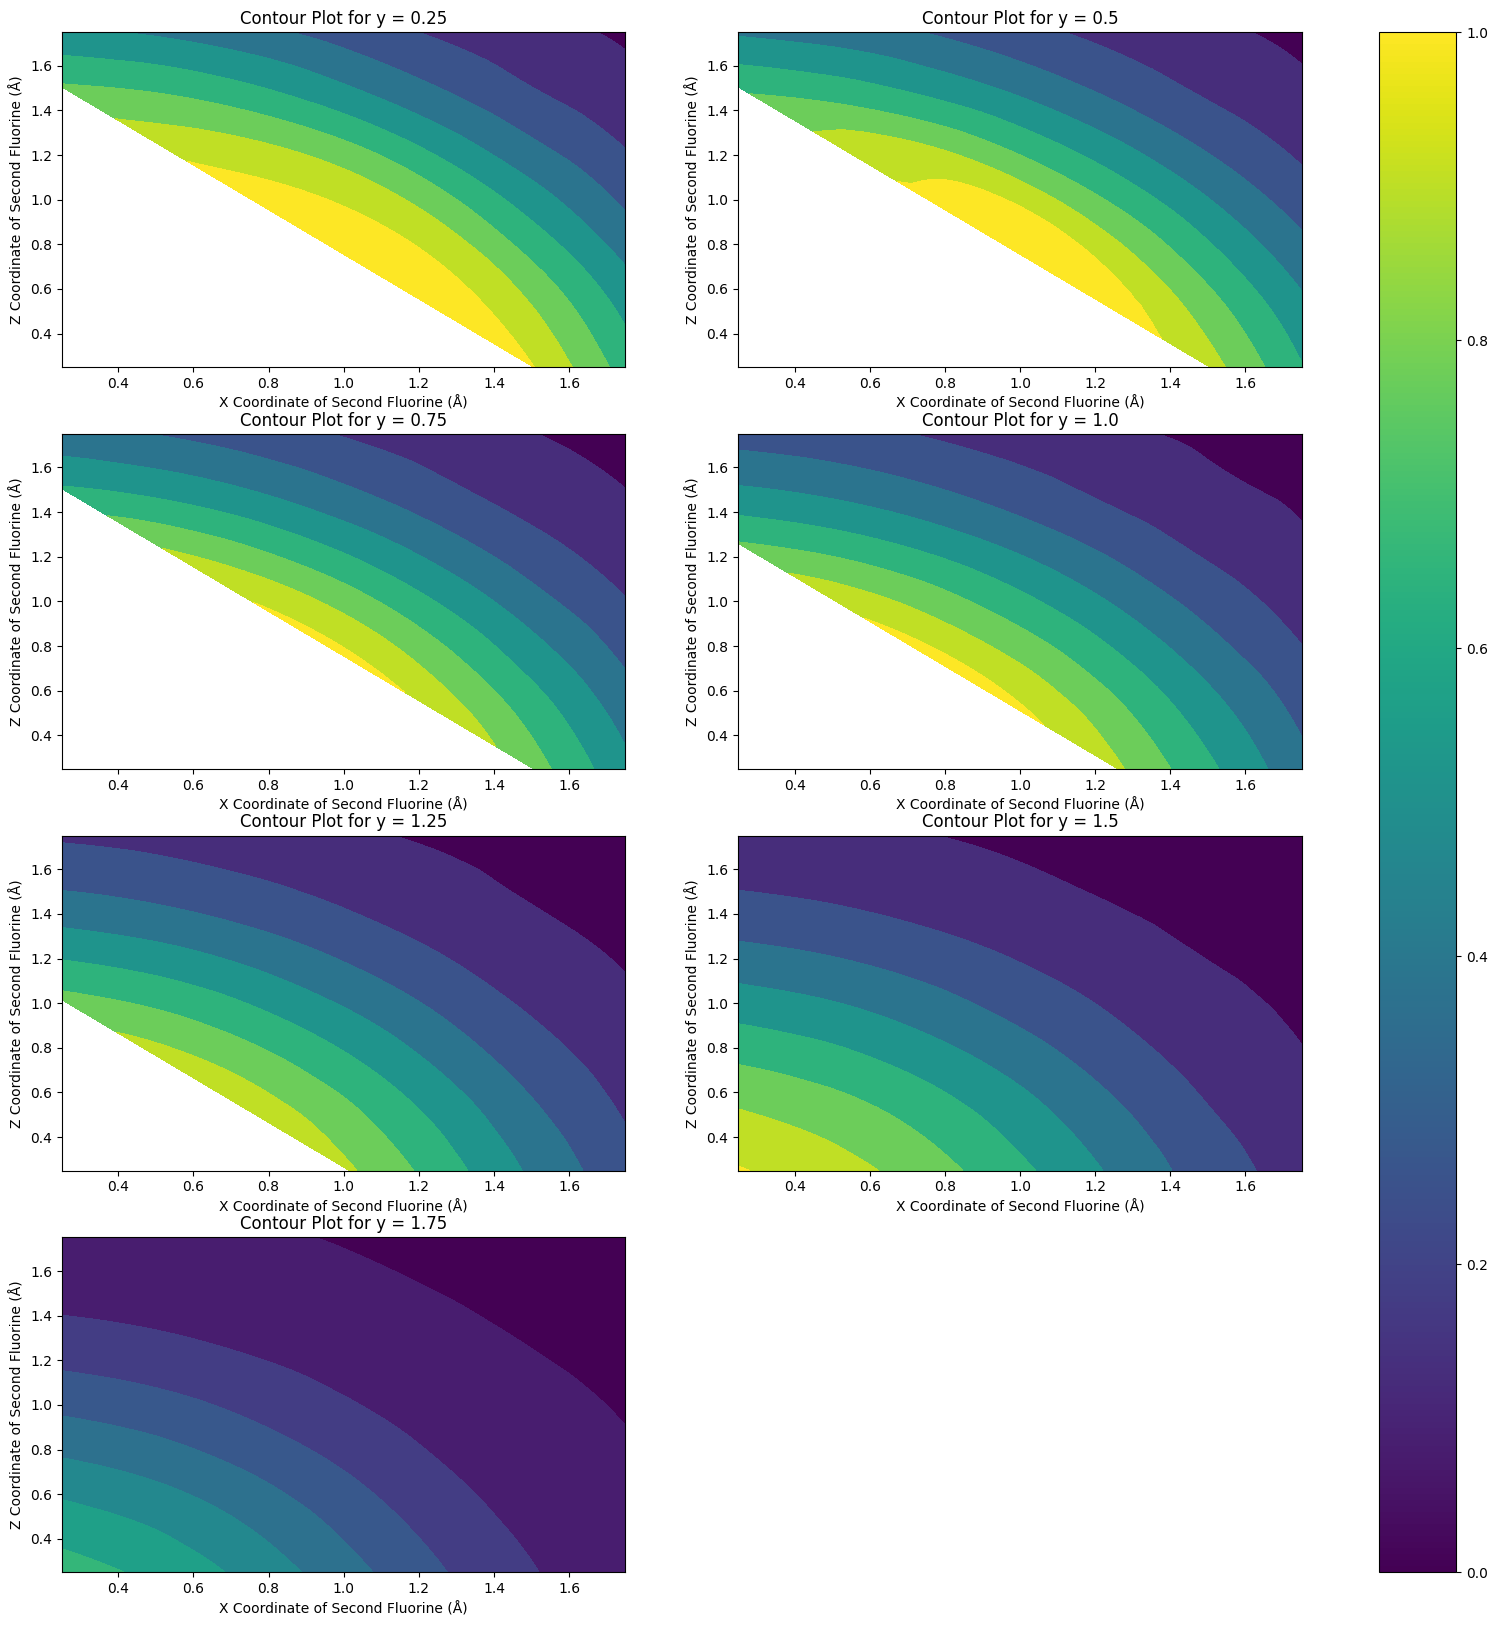

In [80]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))
cmap = cm.get_cmap('viridis')
normalizer = Normalize(0, 4)
vmin = bsse_data_nwchem['BSSE_A'].min() * 627.5096
vmax = bsse_data_nwchem['BSSE_A'].max() * 627.5096
fig.delaxes(axes[3][1])
for i, fixed_y_value in enumerate(np.arange(.25, 2, .25)):
    ax = axes[i // 2, i % 2]
    data = bsse_data_nwchem[bsse_data_nwchem['y'] == fixed_y_value][['x', 'z', 'BSSE_A']]
    xs = data['x'].values
    zs = data['z'].values
    bsse = data['BSSE_A'].values * 627.5096
    # Grid and interpolation
    xi = np.linspace(min(xs), max(xs), 50)
    zi = np.linspace(min(zs), max(zs), 50)
    Xi, Zi = np.meshgrid(xi, zi)
    bssei = griddata((xs, zs), bsse, (Xi, Zi), method='cubic')
    # Filled contour plot with fixed vmin/vmax
    contour = ax.contourf(Xi, Zi, bssei, levels=8, cmap='viridis', vmin=vmin, vmax=vmax)
    # ax.scatter(xs, zs, c=bsse, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='k')

    ax.set_title(f'Contour Plot for y = {fixed_y_value}')
    ax.set_xlabel('X Coordinate of Second Fluorine (Å)')
    ax.set_ylabel('Z Coordinate of Second Fluorine (Å)')
fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()